In [1]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from statsmodels.tsa.statespace.sarimax import SARIMAX
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
import warnings

warnings.filterwarnings('ignore')

2025-11-17 11:14:47.310675: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2025-11-17 11:14:47.310974: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-11-17 11:14:47.348744: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-11-17 11:14:47.998430: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation or

In [2]:
# ========================================
# 1. DOWNLOAD DATA DARI YAHOO FINANCE
# ========================================
print("Mengunduh data IHSG dari Yahoo Finance...")
# ^JKSE adalah ticker untuk IHSG di Yahoo Finance
ticker = "^JKSE"
start_date = "2015-01-01"
end_date = "2024-12-31"

df = yf.download(ticker, start=start_date, end=end_date)
print(f"Data berhasil diunduh: {len(df)} baris")
print(df.head())

# Gunakan kolom Close untuk prediksi
data = df[['Close']].copy()
data.columns = ['IHSG']

Mengunduh data IHSG dari Yahoo Finance...


[*********************100%***********************]  1 of 1 completed

Data berhasil diunduh: 2425 baris
Price             Close         High          Low         Open    Volume
Ticker            ^JKSE        ^JKSE        ^JKSE        ^JKSE     ^JKSE
Date                                                                    
2015-01-02  5242.564941  5247.733685  5230.546366  5233.592146  38133000
2015-01-05  5219.791992  5233.456500  5206.082565  5229.480580  44846100
2015-01-06  5168.858398  5194.600558  5168.858398  5186.001773  51516500
2015-01-07  5206.915039  5207.172842  5174.594034  5175.352306  72088500
2015-01-08  5211.625000  5229.975359  5208.790150  5218.196521  69163000


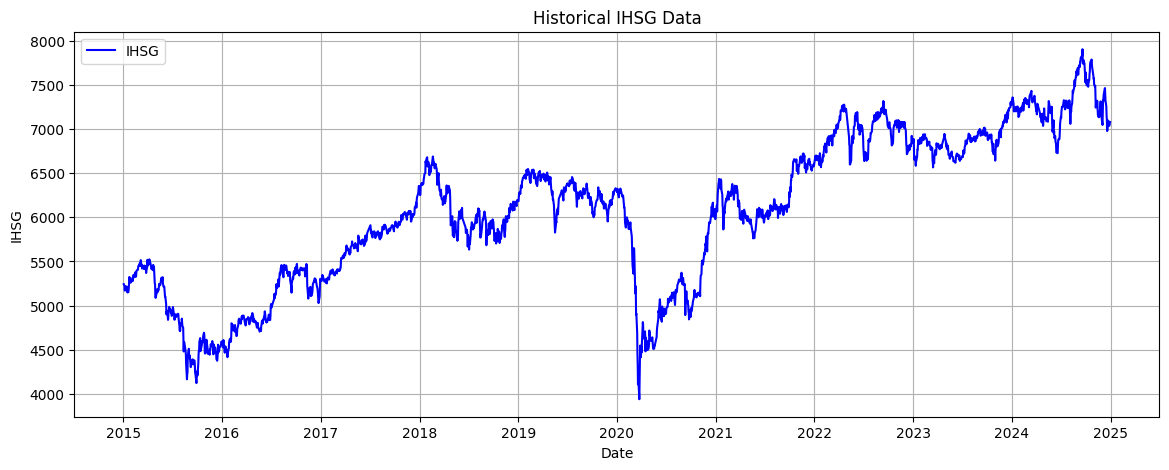

In [3]:
# ========================================
# 2. EXPLORATORY DATA ANALYSIS
# ========================================
plt.figure(figsize=(14, 5))
plt.plot(data.index, data['IHSG'], label='IHSG', color='blue')
plt.title('Historical IHSG Data')
plt.xlabel('Date')
plt.ylabel('IHSG')
plt.legend()
plt.grid(True)
plt.show()

In [4]:
# ========================================
# 3. SPLIT DATA (80% TRAIN, 20% TEST)
# ========================================
train_size = int(len(data) * 0.8)
train_data = data[:train_size]
test_data = data[train_size:]

print(f"Training data: {len(train_data)} baris")
print(f"Testing data: {len(test_data)} baris")

Training data: 1940 baris
Testing data: 485 baris


In [5]:
# ========================================
# 4. MODEL ARIMAX
# ========================================
print("\n=== Tahap 1: Modeling ARIMAX ===")

# Tambahkan variabel eksogen (contoh: moving average, lag features)
train_arimax = train_data.copy()
train_arimax['MA7'] = train_arimax['IHSG'].rolling(window=7).mean()
train_arimax['MA30'] = train_arimax['IHSG'].rolling(window=30).mean()
train_arimax = train_arimax.dropna()

test_arimax = test_data.copy()
test_arimax['MA7'] = test_arimax['IHSG'].rolling(window=7).mean()
test_arimax['MA30'] = test_arimax['IHSG'].rolling(window=30).mean()
test_arimax = test_arimax.dropna()

# Variabel eksogen
exog_train = train_arimax[['MA7', 'MA30']]
exog_test = test_arimax[['MA7', 'MA30']]

# Fit ARIMAX model (order dapat disesuaikan)
# Format: SARIMAX(endog, exog, order=(p,d,q))
print("Fitting ARIMAX model...")
arimax_model = SARIMAX(train_arimax['IHSG'],
                       exog=exog_train,
                       order=(2, 1, 2),  # (p, d, q) - bisa di-tuning
                       enforce_stationarity=False,
                       enforce_invertibility=False)

arimax_fit = arimax_model.fit(disp=False)
print("ARIMAX model berhasil di-fit")

# Prediksi dengan ARIMAX
arimax_pred_train = arimax_fit.predict(start=0, end=len(train_arimax) - 1, exog=exog_train)
arimax_pred_test = arimax_fit.predict(start=len(train_arimax),
                                      end=len(train_arimax) + len(test_arimax) - 1,
                                      exog=exog_test)

# Hitung residual (error) dari ARIMAX
residual_train = train_arimax['IHSG'] - arimax_pred_train
residual_test = test_arimax['IHSG'] - arimax_pred_test

print(f"ARIMAX RMSE on test: {np.sqrt(mean_squared_error(test_arimax['IHSG'], arimax_pred_test)):.2f}")



=== Tahap 1: Modeling ARIMAX ===
Fitting ARIMAX model...
ARIMAX model berhasil di-fit
ARIMAX RMSE on test: 67.29


In [6]:
# ========================================
# 5. MODEL LSTM UNTUK RESIDUAL
# ========================================
print("\n=== Tahap 2: Modeling LSTM untuk Residual ===")


# Fungsi untuk membuat dataset supervised learning
def create_dataset(data, look_back=30):
    X, y = [], []
    for i in range(look_back, len(data)):
        X.append(data[i - look_back:i])
        y.append(data[i])
    return np.array(X), np.array(y)


# SOLUSI: Gabungkan train dan test residual untuk membuat sequence yang kontinyu
# Ini penting karena LSTM membutuhkan look_back data sebelumnya
residual_all = pd.concat([residual_train, residual_test])
print(f"Total residual length: {len(residual_all)}")
print(f"Residual train length: {len(residual_train)}")
print(f"Residual test length: {len(residual_test)}")

# Normalisasi residual
scaler = MinMaxScaler(feature_range=(0, 1))
residual_all_scaled = scaler.fit_transform(residual_all.values.reshape(-1, 1))

# Buat dataset untuk LSTM
look_back = 30
X_all, y_all = create_dataset(residual_all_scaled, look_back)

# Split kembali menjadi train dan test
# Train: dari awal sampai panjang residual_train
# Test: sisanya
train_lstm_size = len(residual_train) - look_back
X_train_lstm = X_all[:train_lstm_size]
y_train_lstm = y_all[:train_lstm_size]
X_test_lstm = X_all[train_lstm_size:]
y_test_lstm = y_all[train_lstm_size:]

# Reshape untuk LSTM [samples, time steps, features]
X_train_lstm = X_train_lstm.reshape(X_train_lstm.shape[0], X_train_lstm.shape[1], 1)
X_test_lstm = X_test_lstm.reshape(X_test_lstm.shape[0], X_test_lstm.shape[1], 1)

print(f"LSTM Training shape: {X_train_lstm.shape}")
print(f"LSTM Testing shape: {X_test_lstm.shape}")
print(f"Y train shape: {y_train_lstm.shape}")
print(f"Y test shape: {y_test_lstm.shape}")

# Build LSTM model
lstm_model = Sequential([
    LSTM(50, return_sequences=True, input_shape=(look_back, 1)),
    Dropout(0.2),
    LSTM(50, return_sequences=False),
    Dropout(0.2),
    Dense(25),
    Dense(1)
])

lstm_model.compile(optimizer='adam', loss='mean_squared_error')

# Early stopping
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

# Train LSTM
print("Training LSTM model...")
history = lstm_model.fit(
    X_train_lstm, y_train_lstm,
    batch_size=32,
    epochs=50,
    validation_split=0.1,
    callbacks=[early_stop],
    verbose=1
)

# Prediksi residual dengan LSTM
lstm_pred_train_scaled = lstm_model.predict(X_train_lstm)
lstm_pred_test_scaled = lstm_model.predict(X_test_lstm)

# Inverse transform
lstm_pred_train = scaler.inverse_transform(lstm_pred_train_scaled)
lstm_pred_test = scaler.inverse_transform(lstm_pred_test_scaled)



=== Tahap 2: Modeling LSTM untuk Residual ===
Total residual length: 2823
Residual train length: 1911
Residual test length: 912
LSTM Training shape: (1881, 30, 1)
LSTM Testing shape: (912, 30, 1)
Y train shape: (1881, 1)
Y test shape: (912, 1)
Training LSTM model...
Epoch 1/50


E0000 00:00:1763352890.332286   33010 cuda_executor.cc:1309] INTERNAL: CUDA Runtime error: Failed call to cudaGetRuntimeVersion: Error loading CUDA libraries. GPU will not be used.: Error loading CUDA libraries. GPU will not be used.
W0000 00:00:1763352890.341778   33010 gpu_device.cc:2342] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


53/53 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 0.0190 - val_loss: 0.0068
Epoch 2/50
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0072 - val_loss: 0.0062
Epoch 3/50
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0066 - val_loss: 0.0061
Epoch 4/50
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0064 - val_loss: 0.0060
Epoch 5/50
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0062 - val_loss: 0.0067
Epoch 6/50
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0060 - val_loss: 0.0060
Epoch 7/50
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0058 - val_loss: 0.0061
Epoch 8/50
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0056 - val_loss: 0.0060
Epoch 9/50
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0057 - val_loss: 0.0060
Epoch 10/50
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0057 - val_loss: 0.0060
Epoch 11/50
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0056 - val_loss: 0.0060
Epoch 12/50
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0055 - val_loss: 0.0060

In [7]:
# ========================================
# 6. HYBRID MODEL (ARIMAX + LSTM)
# ========================================
print("\n=== Tahap 3: Kombinasi ARIMAX + LSTM ===")

# Debug: Cek panjang data
print(f"Length arimax_pred_train: {len(arimax_pred_train)}")
print(f"Length lstm_pred_train: {len(lstm_pred_train)}")
print(f"Length arimax_pred_test: {len(arimax_pred_test)}")
print(f"Length lstm_pred_test: {len(lstm_pred_test)}")
print(f"train_lstm_size: {train_lstm_size}")
print(f"Length residual_train: {len(residual_train)}")
print(f"Length residual_test: {len(residual_test)}")

# Untuk train: mulai dari look_back
min_train_len = len(lstm_pred_train)
arimax_train_aligned = arimax_pred_train.values[look_back:look_back + min_train_len]
lstm_train_aligned = lstm_pred_train.flatten()
actual_train_aligned = train_arimax['IHSG'].values[look_back:look_back + min_train_len]

# Untuk test:
# lstm_pred_test berisi prediksi mulai dari index train_lstm_size
# yang berarti dari posisi len(residual_train) - look_back + look_back = len(residual_train)
# Jadi lstm_pred_test sebenarnya prediksi untuk residual mulai index len(residual_train)
# Di sisi lain, arimax_pred_test adalah prediksi untuk test_arimax yang dimulai dari index 0

# Karena LSTM dibuat dari gabungan train+test, kita perlu offset
# LSTM prediksi ke-0 di test sebenarnya untuk residual index len(residual_train)
# Sedangkan ARIMAX prediksi ke-0 di test untuk test_arimax index 0
# test_arimax dimulai setelah dropna MA, jadi ada offset

# Cara paling aman: gunakan panjang minimum yang tersedia
min_test_len = min(len(lstm_pred_test), len(arimax_pred_test))

print(f"\nDebug test alignment:")
print(f"min_test_len: {min_test_len}")

# Ambil data sesuai min_test_len
arimax_test_aligned = arimax_pred_test.values[:min_test_len]
lstm_test_aligned = lstm_pred_test[:min_test_len].flatten()
actual_test_aligned = test_arimax['IHSG'].values[:min_test_len]

# Gabungkan ARIMAX + LSTM
hybrid_train = arimax_train_aligned + lstm_train_aligned
hybrid_test = arimax_test_aligned + lstm_test_aligned

# Cek dan handle NaN values
print(f"\nChecking for NaN values:")
print(f"NaN in arimax_train_aligned: {np.isnan(arimax_train_aligned).sum()}")
print(f"NaN in lstm_train_aligned: {np.isnan(lstm_train_aligned).sum()}")
print(f"NaN in hybrid_train: {np.isnan(hybrid_train).sum()}")
print(f"NaN in arimax_test_aligned: {np.isnan(arimax_test_aligned).sum()}")
print(f"NaN in lstm_test_aligned: {np.isnan(lstm_test_aligned).sum()}")
print(f"NaN in hybrid_test: {np.isnan(hybrid_test).sum()}")
print(f"NaN in actual_test_aligned: {np.isnan(actual_test_aligned).sum()}")

# Remove NaN values jika ada
if np.isnan(hybrid_train).any() or np.isnan(hybrid_test).any() or np.isnan(actual_test_aligned).any():
    print("\nRemoving NaN values...")
    # Untuk train
    mask_train = ~(np.isnan(hybrid_train) | np.isnan(actual_train_aligned))
    hybrid_train = hybrid_train[mask_train]
    arimax_train_aligned = arimax_train_aligned[mask_train]
    actual_train_aligned = actual_train_aligned[mask_train]

    # Untuk test
    mask_test = ~(np.isnan(hybrid_test) | np.isnan(actual_test_aligned) | np.isnan(arimax_test_aligned))
    hybrid_test = hybrid_test[mask_test]
    arimax_test_aligned = arimax_test_aligned[mask_test]
    actual_test_aligned = actual_test_aligned[mask_test]

    print(f"After removing NaN:")
    print(f"Length hybrid_train: {len(hybrid_train)}")
    print(f"Length hybrid_test: {len(hybrid_test)}")

# Assign ke variabel yang lebih sederhana
actual_train = actual_train_aligned
actual_test = actual_test_aligned

print(f"\nFinal alignment:")
print(f"Length hybrid_train: {len(hybrid_train)}")
print(f"Length hybrid_test: {len(hybrid_test)}")
print(f"Length actual_train: {len(actual_train)}")
print(f"Length actual_test: {len(actual_test)}")



=== Tahap 3: Kombinasi ARIMAX + LSTM ===
Length arimax_pred_train: 1911
Length lstm_pred_train: 1881
Length arimax_pred_test: 456
Length lstm_pred_test: 912
train_lstm_size: 1881
Length residual_train: 1911
Length residual_test: 912

Debug test alignment:
min_test_len: 456

Checking for NaN values:
NaN in arimax_train_aligned: 0
NaN in lstm_train_aligned: 0
NaN in hybrid_train: 0
NaN in arimax_test_aligned: 0
NaN in lstm_test_aligned: 455
NaN in hybrid_test: 455
NaN in actual_test_aligned: 0

Removing NaN values...
After removing NaN:
Length hybrid_train: 1881
Length hybrid_test: 1

Final alignment:
Length hybrid_train: 1881
Length hybrid_test: 1
Length actual_train: 1881
Length actual_test: 1


In [8]:
# ========================================
# 7. EVALUASI MODEL
# ========================================
print("\n=== Evaluasi Model ===")


def evaluate_model(actual, predicted, model_name):
    rmse = np.sqrt(mean_squared_error(actual, predicted))
    mae = mean_absolute_error(actual, predicted)
    r2 = r2_score(actual, predicted)
    mape = np.mean(np.abs((actual - predicted) / actual)) * 100

    print(f"\n{model_name}:")
    print(f"  RMSE: {rmse:.2f}")
    print(f"  MAE: {mae:.2f}")
    print(f"  R2 Score: {r2:.4f}")
    print(f"  MAPE: {mape:.2f}%")

    return rmse, mae, r2, mape


# Evaluasi ARIMAX saja (dengan aligned data)
if len(actual_test) > 0:
    evaluate_model(actual_test, arimax_test_aligned, "ARIMAX Only (Test)")
else:
    print("\nWarning: No test data available after alignment!")
    print("Evaluating on available ARIMAX test predictions:")
    evaluate_model(test_arimax['IHSG'].values, arimax_pred_test.values, "ARIMAX Only (Full Test)")

# Evaluasi Hybrid
if len(actual_test) > 0:
    evaluate_model(actual_test, hybrid_test, "Hybrid ARIMAX-LSTM (Test)")
else:
    print("\nSkipping Hybrid evaluation - no test data after alignment")



=== Evaluasi Model ===

ARIMAX Only (Test):
  RMSE: 95.43
  MAE: 95.43
  R2 Score: nan
  MAPE: 1.40%

Hybrid ARIMAX-LSTM (Test):
  RMSE: 98.26
  MAE: 98.26
  R2 Score: nan
  MAPE: 1.44%


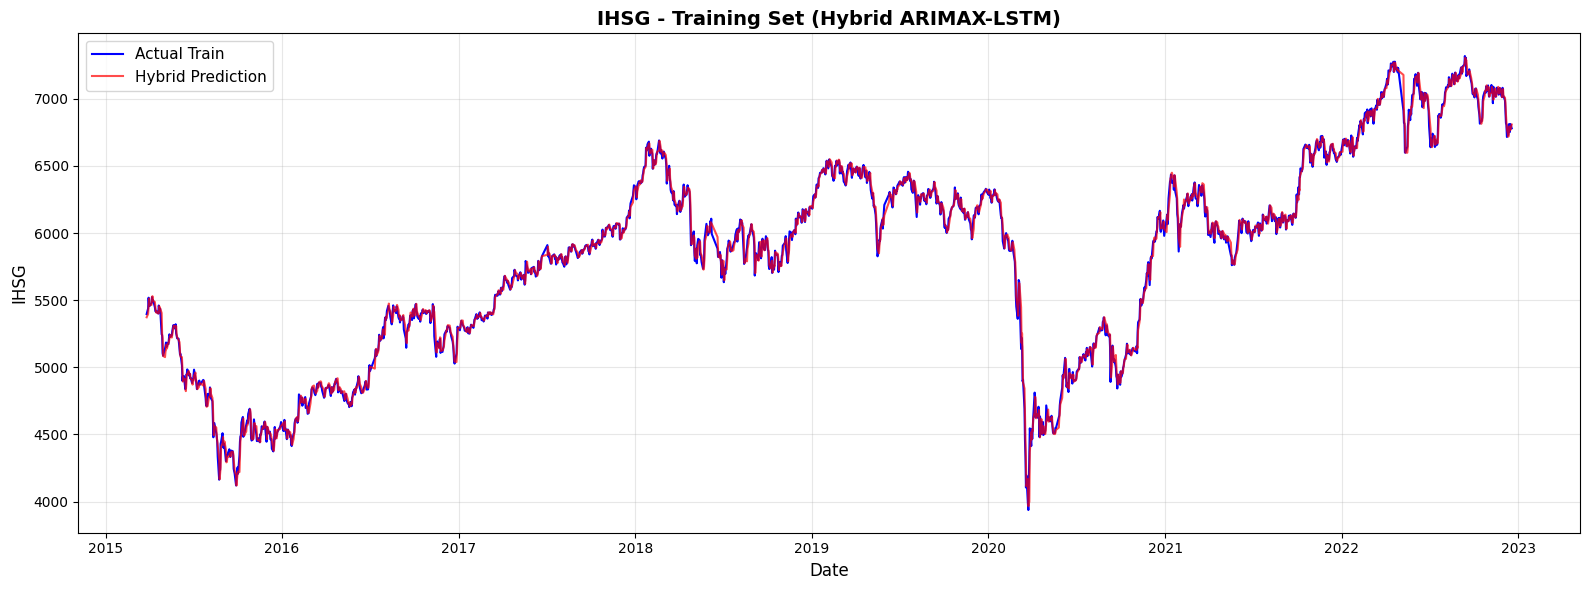

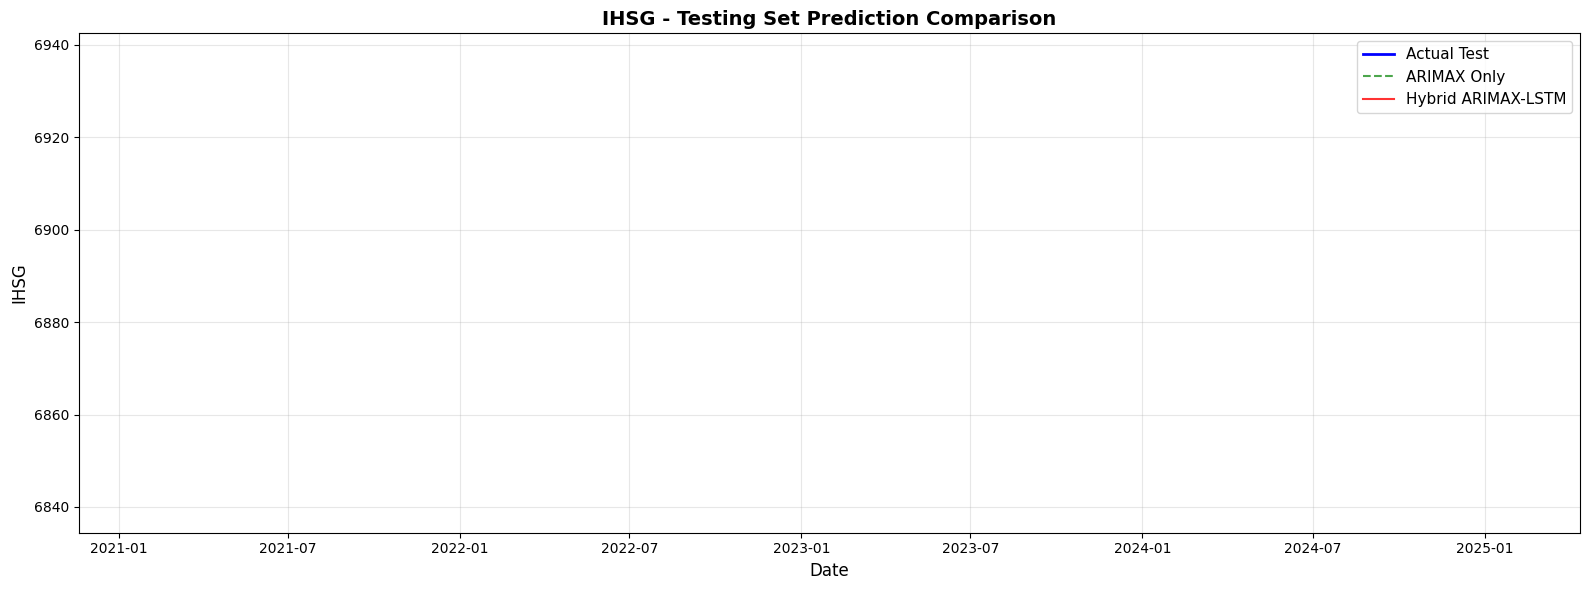

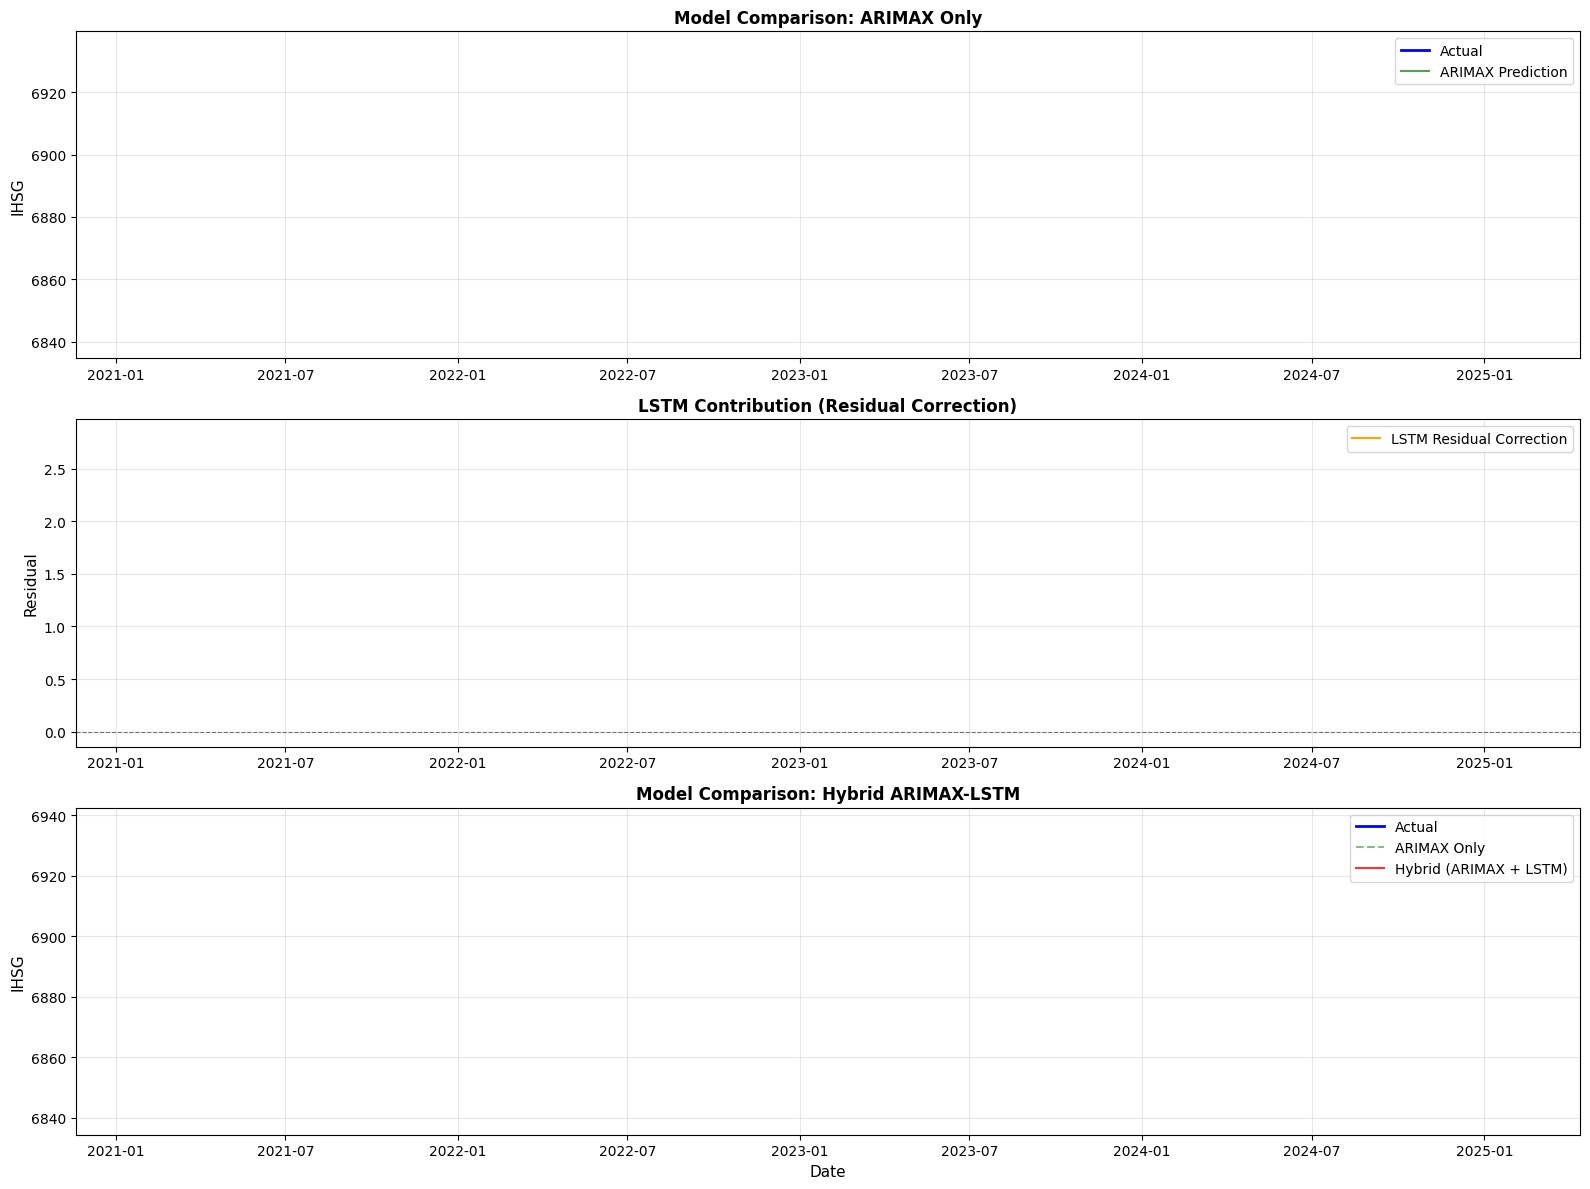

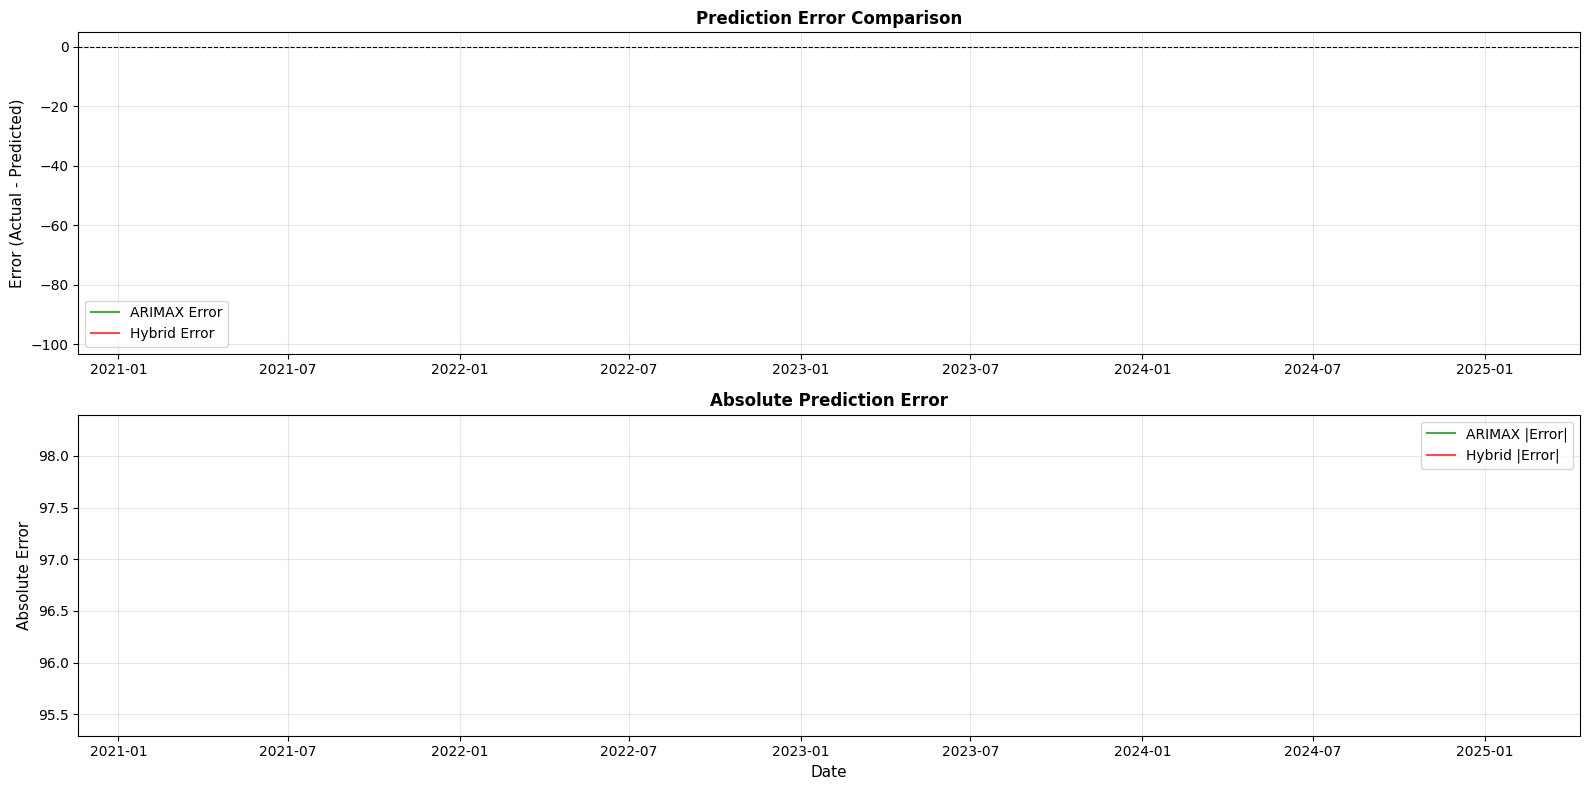

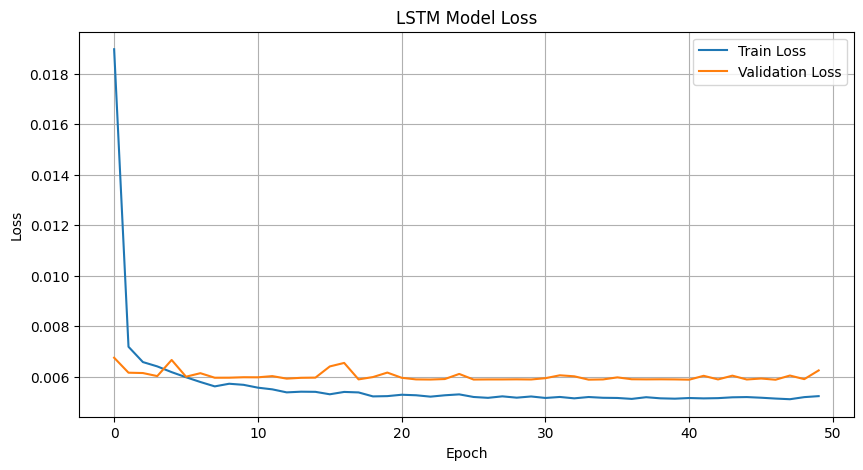

In [11]:
# ========================================
# 8. VISUALISASI HASIL
# ========================================

# Plot 1: Training Set
if len(hybrid_train) > 0:
    plt.figure(figsize=(16, 6))
    train_dates = train_arimax.index[look_back:look_back + len(hybrid_train)]
    plt.plot(train_dates, actual_train, label='Actual Train', color='blue', linewidth=1.5)
    plt.plot(train_dates, hybrid_train, label='Hybrid Prediction', color='red', linewidth=1.5, alpha=0.7)
    plt.title('IHSG - Training Set (Hybrid ARIMAX-LSTM)', fontsize=14, fontweight='bold')
    plt.xlabel('Date', fontsize=12)
    plt.ylabel('IHSG', fontsize=12)
    plt.legend(fontsize=11)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

# Plot 2: Testing Set - Comparison
if len(hybrid_test) > 0:
    plt.figure(figsize=(16, 6))
    test_dates = test_arimax.index[:len(hybrid_test)]

    plt.plot(test_dates, actual_test, label='Actual Test', color='blue', linewidth=2)
    plt.plot(test_dates, arimax_test_aligned, label='ARIMAX Only',
             color='green', linewidth=1.5, alpha=0.7, linestyle='--')
    plt.plot(test_dates, hybrid_test, label='Hybrid ARIMAX-LSTM',
             color='red', linewidth=1.5, alpha=0.8)

    plt.title('IHSG - Testing Set Prediction Comparison', fontsize=14, fontweight='bold')
    plt.xlabel('Date', fontsize=12)
    plt.ylabel('IHSG', fontsize=12)
    plt.legend(fontsize=11)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
else:
    print("\nWarning: No test data available for plotting after alignment")
    print("Plotting full ARIMAX predictions instead...")

    plt.figure(figsize=(16, 6))
    plt.plot(test_arimax.index, test_arimax['IHSG'], label='Actual Test',
             color='blue', linewidth=2)
    plt.plot(test_arimax.index, arimax_pred_test.values, label='ARIMAX Prediction',
             color='green', linewidth=1.5, alpha=0.7, linestyle='--')
    plt.title('IHSG - Testing Set (ARIMAX Only)', fontsize=14, fontweight='bold')
    plt.xlabel('Date', fontsize=12)
    plt.ylabel('IHSG', fontsize=12)
    plt.legend(fontsize=11)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

# Plot 3: Model Comparison - ARIMAX vs LSTM Residual vs Hybrid
if len(hybrid_test) > 0:
    fig, axes = plt.subplots(3, 1, figsize=(16, 12))
    test_dates = test_arimax.index[:len(hybrid_test)]

    # ARIMAX Only
    axes[0].plot(test_dates, actual_test, label='Actual', color='blue', linewidth=2)
    axes[0].plot(test_dates, arimax_test_aligned, label='ARIMAX Prediction',
                 color='green', linewidth=1.5, alpha=0.7)
    axes[0].set_title('Model Comparison: ARIMAX Only', fontsize=12, fontweight='bold')
    axes[0].set_ylabel('IHSG', fontsize=11)
    axes[0].legend(fontsize=10)
    axes[0].grid(True, alpha=0.3)

    # ARIMAX + LSTM Residual Correction
    lstm_contribution = lstm_test_aligned[:len(hybrid_test)]
    axes[1].plot(test_dates, lstm_contribution, label='LSTM Residual Correction',
                 color='orange', linewidth=1.5)
    axes[1].axhline(y=0, color='black', linestyle='--', linewidth=0.8, alpha=0.5)
    axes[1].set_title('LSTM Contribution (Residual Correction)', fontsize=12, fontweight='bold')
    axes[1].set_ylabel('Residual', fontsize=11)
    axes[1].legend(fontsize=10)
    axes[1].grid(True, alpha=0.3)

    # Hybrid Model
    axes[2].plot(test_dates, actual_test, label='Actual', color='blue', linewidth=2)
    axes[2].plot(test_dates, arimax_test_aligned, label='ARIMAX Only',
                 color='green', linewidth=1.5, alpha=0.5, linestyle='--')
    axes[2].plot(test_dates, hybrid_test, label='Hybrid (ARIMAX + LSTM)',
                 color='red', linewidth=1.5, alpha=0.8)
    axes[2].set_title('Model Comparison: Hybrid ARIMAX-LSTM', fontsize=12, fontweight='bold')
    axes[2].set_xlabel('Date', fontsize=11)
    axes[2].set_ylabel('IHSG', fontsize=11)
    axes[2].legend(fontsize=10)
    axes[2].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

# Plot 4: Error Analysis
if len(hybrid_test) > 0:
    fig, axes = plt.subplots(2, 1, figsize=(16, 8))
    test_dates = test_arimax.index[:len(hybrid_test)]

    # Error comparison
    arimax_error = actual_test - arimax_test_aligned
    hybrid_error = actual_test - hybrid_test

    axes[0].plot(test_dates, arimax_error, label='ARIMAX Error',
                 color='green', linewidth=1.5, alpha=0.7)
    axes[0].plot(test_dates, hybrid_error, label='Hybrid Error',
                 color='red', linewidth=1.5, alpha=0.7)
    axes[0].axhline(y=0, color='black', linestyle='--', linewidth=0.8)
    axes[0].set_title('Prediction Error Comparison', fontsize=12, fontweight='bold')
    axes[0].set_ylabel('Error (Actual - Predicted)', fontsize=11)
    axes[0].legend(fontsize=10)
    axes[0].grid(True, alpha=0.3)

    # Absolute error comparison
    axes[1].plot(test_dates, np.abs(arimax_error), label='ARIMAX |Error|',
                 color='green', linewidth=1.5, alpha=0.7)
    axes[1].plot(test_dates, np.abs(hybrid_error), label='Hybrid |Error|',
                 color='red', linewidth=1.5, alpha=0.7)
    axes[1].set_title('Absolute Prediction Error', fontsize=12, fontweight='bold')
    axes[1].set_xlabel('Date', fontsize=11)
    axes[1].set_ylabel('Absolute Error', fontsize=11)
    axes[1].legend(fontsize=10)
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

# Plot training loss LSTM
plt.figure(figsize=(10, 5))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('LSTM Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()


=== Prediksi 30 Hari ke Depan ===
Prediksi IHSG 30 hari ke depan (ARIMAX):
1911    7278.656279
1912    7238.329687
1913    7217.231754
1914    7198.470985
1915    7179.886662
1916    7144.361470
1917    7121.027002
1918    7135.410740
1919    7148.772540
1920    7159.942991
1921    7146.856178
1922    7125.920361
1923    7138.173912
1924    7163.667447
1925    7166.196759
1926    7192.647903
1927    7236.871593
1928    7298.945872
1929    7375.047281
1930    7412.370327
1931    7414.655929
1932    7407.588421
1933    7370.733784
1934    7315.674858
1935    7234.638985
1936    7151.452209
1937    7100.376192
1938    7056.250913
1939    7019.389743
1940    7007.775540
Name: predicted_mean, dtype: float64


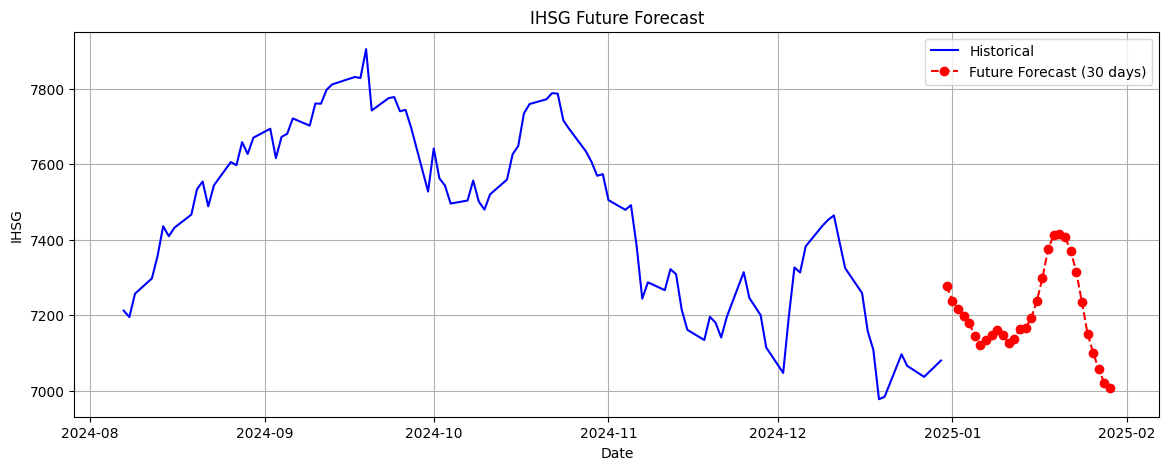


=== Selesai ===
Model hybrid ARIMAX-LSTM telah berhasil diimplementasikan!


In [10]:
# ========================================
# 9. PREDIKSI MASA DEPAN (CONTOH)
# ========================================
print("\n=== Prediksi 30 Hari ke Depan ===")

# Untuk prediksi masa depan, kita perlu menggunakan data terakhir
last_data = data.tail(60).copy()
last_data['MA7'] = last_data['IHSG'].rolling(window=7).mean()
last_data['MA30'] = last_data['IHSG'].rolling(window=30).mean()
last_data = last_data.dropna()

# Prediksi ARIMAX untuk 30 hari ke depan
future_exog = last_data[['MA7', 'MA30']].tail(30)  # Gunakan MA terakhir sebagai proxy
future_arimax = arimax_fit.forecast(steps=30, exog=future_exog)

print(f"Prediksi IHSG 30 hari ke depan (ARIMAX):")
print(future_arimax)

# Plot prediksi masa depan
plt.figure(figsize=(14, 5))
plt.plot(data.index[-100:], data['IHSG'][-100:], label='Historical', color='blue')
future_dates = pd.date_range(start=data.index[-1], periods=31, freq='D')[1:]
plt.plot(future_dates, future_arimax, label='Future Forecast (30 days)',
         color='red', marker='o', linestyle='--')
plt.title('IHSG Future Forecast')
plt.xlabel('Date')
plt.ylabel('IHSG')
plt.legend()
plt.grid(True)
plt.show()

print("\n=== Selesai ===")
print("Model hybrid ARIMAX-LSTM telah berhasil diimplementasikan!")